## Predicting Survival on the Titanic

### History
Perhaps one of the most infamous shipwrecks in history, the Titanic sank after colliding with an iceberg, killing 1502 out of 2224 people on board. Interestingly, by analysing the probability of survival based on few attributes like gender, age, and social status, we can make very accurate predictions on which passengers would survive. Some groups of people were more likely to survive than others, such as women, children, and the upper-class. Therefore, we can learn about the society priorities and privileges at the time.

### Assignment:

Build a Machine Learning Pipeline, to engineer the features in the data set and predict who is more likely to Survive the catastrophe.

Follow the Jupyter notebook below, and complete the missing bits of code, to achieve each one of the pipeline steps.

In [100]:
import re

# to handle datasets
import pandas as pd
import numpy as np

# for visualization
import matplotlib.pyplot as plt

# to divide train and test set
from sklearn.model_selection import train_test_split

# feature scaling
from sklearn.preprocessing import StandardScaler

# to build the models
from sklearn.linear_model import LogisticRegression

# to evaluate the models
from sklearn.metrics import accuracy_score, roc_auc_score

# to persist the model and the scaler
import joblib

# to visualise al the columns in the dataframe
pd.pandas.set_option('display.max_columns', None)

## Prepare the data set

In [101]:
# load the data - it is available open source and online

data = pd.read_csv('https://www.openml.org/data/get_csv/16826755/phpMYEkMl')

# display data
data.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.55,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30,1,2,113781,151.55,C22 C26,S,?,135,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"


In [102]:
# replace interrogation marks by NaN values

data = data.replace('?', np.nan)

In [103]:
# retain only the first cabin if more than
# 1 are available per passenger

def get_first_cabin(row):
    try:
        return row.split()[0]
    except:
        return np.nan
    
data['cabin'] = data['cabin'].apply(get_first_cabin)

In [104]:
# extracts the title (Mr, Ms, etc) from the name variable

def get_title(passenger):
    line = passenger
    if re.search('Mrs', line):
        return 'Mrs'
    elif re.search('Mr', line):
        return 'Mr'
    elif re.search('Miss', line):
        return 'Miss'
    elif re.search('Master', line):
        return 'Master'
    else:
        return 'Other'
    
data['title'] = data['name'].apply(get_title)

In [105]:
# cast numerical variables as floats

data['fare'] = data['fare'].astype('float')
data['age'] = data['age'].astype('float')

In [106]:
# drop unnecessary variables

data.drop(labels=['name','ticket', 'boat', 'body','home.dest'], axis=1, inplace=True)

# display data
data.head()

,pclass,survived,sex,age,sibsp,parch,fare,cabin,embarked,title
0,1,1,female,29.0000,0,0,211.3375,B5,S,Miss
1,1,1,male,0.9167,1,2,151.5500,C22,S,Master
2,1,0,female,2.0000,1,2,151.5500,C22,S,Miss
3,1,0,male,30.0000,1,2,151.5500,C22,S,Mr
4,1,0,female,25.0000,1,2,151.5500,C22,S,Mrs


In [107]:
# save the data set

data.to_csv('titanic.csv', index=False)

## Data Exploration

### Find numerical and categorical variables

In [108]:
target = 'survived'

In [109]:


vars_cat = [var for var in data.columns if data[var].dtype == 'O']

vars_num = [var for var in data.columns if var not in vars_cat]

print('Number of numerical variables: {}'.format(len(vars_num)))
print('Number of categorical variables: {}'.format(len(vars_cat)))

Number of numerical variables: 6
Number of categorical variables: 4


### Find missing values in variables

In [110]:
# first in numerical variables
print(data.shape)
data[vars_num].isnull().sum().sort_values(ascending=False)
#data[vars_num]


(1309, 10)


age         263
fare          1
survived      0
pclass        0
sibsp         0
parch         0
dtype: int64

In [111]:
# now in categorical variables
print(data.shape)
data[vars_cat].isnull().sum().sort_values(ascending=False)



(1309, 10)


cabin       1014
embarked       2
sex            0
title          0
dtype: int64

### Determine cardinality of categorical variables

Index(['sex', 'cabin', 'embarked', 'title'], dtype='object')


<Axes: >

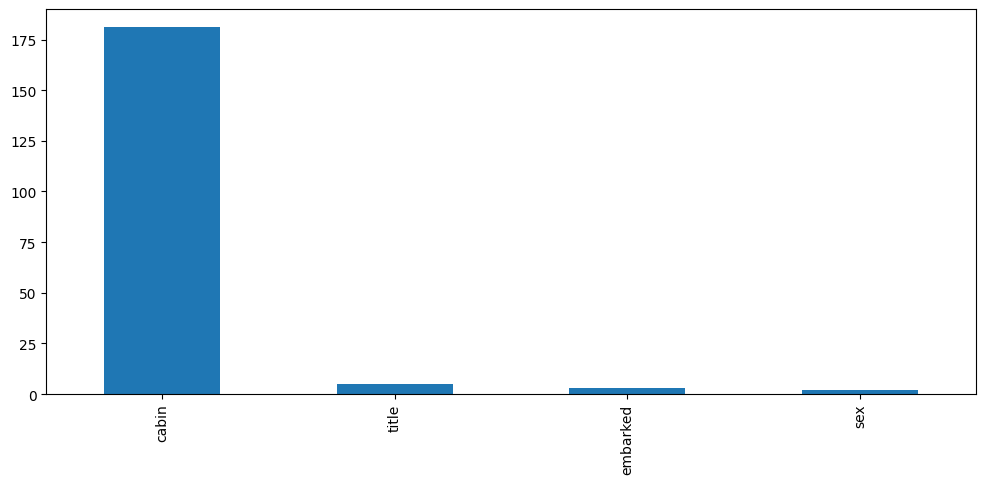

In [112]:
print(data[vars_cat].columns)
data[vars_cat].nunique().sort_values(ascending=False).plot.bar(figsize=(12,5))
#print(data.sex.value_counts())
#print(data.cabin.value_counts())
#print(data.embarked.value_counts())
#print(data.title.value_counts())

### Determine the distribution of numerical variables

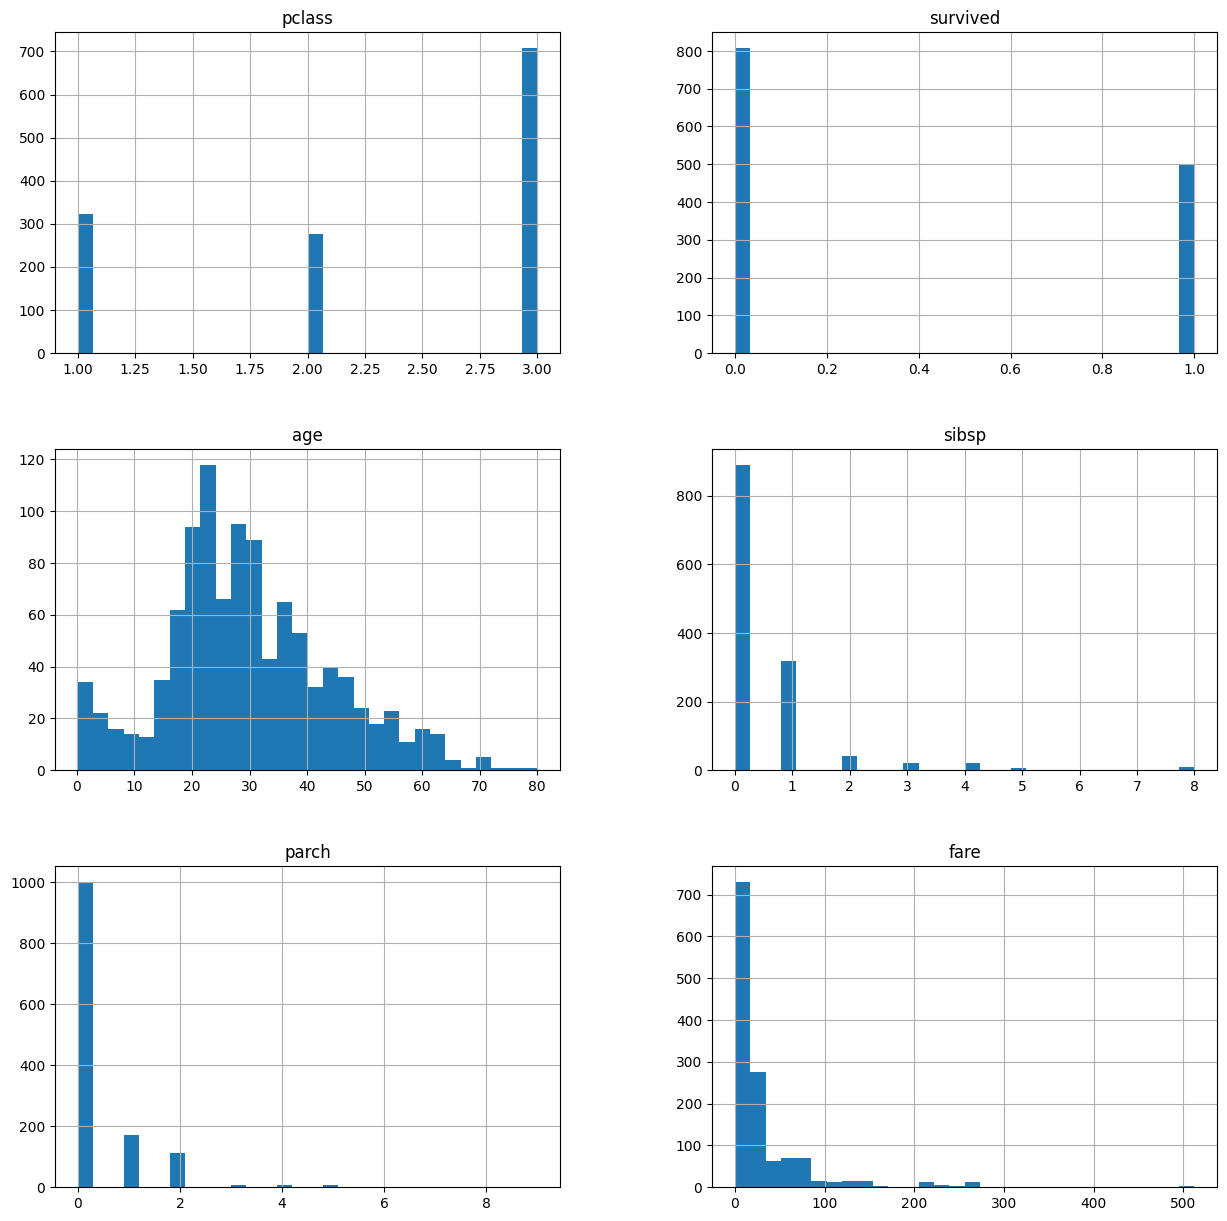

In [113]:
#data[vars_num]

data[vars_num].hist(bins=30, figsize=(15,15))
plt.show()

## Separate data into train and test

Use the code below for reproducibility. Don't change it.

In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop('survived', axis=1),  # predictors
    data['survived'],  # target
    test_size=0.2,  # percentage of obs in test set
    random_state=0)  # seed to ensure reproducibility

X_train.shape, X_test.shape

((1047, 9), (262, 9))

## Feature Engineering

### Extract only the letter (and drop the number) from the variable Cabin

In [115]:
#data["cabin"].unique()
data['cabin_first_letter'] = data['cabin'].str[0]
data['cabin_first_letter'] = data['cabin_first_letter'].where(data['cabin'].notna(), np.nan)
print(data['cabin_first_letter'].unique())

X_train['cabin_first_letter'] = X_train['cabin'].str[0]
X_train['cabin_first_letter'] = X_train['cabin_first_letter'].where(X_train['cabin'].notna(), np.nan)

X_test['cabin_first_letter'] = X_test['cabin'].str[0]
X_test['cabin_first_letter'] = X_test['cabin_first_letter'].where(X_test['cabin'].notna(), np.nan)

['B' 'C' 'E' 'D' 'A' nan 'T' 'F' 'G']


### Fill in Missing data in numerical variables:

- Add a binary missing indicator
- Fill NA in original variable with the median

In [116]:
print(data.shape)
print(X_test.shape)
print(X_train.shape)
data.head()

(1309, 11)
(262, 10)
(1047, 10)


,pclass,survived,sex,age,sibsp,parch,fare,cabin,embarked,title,cabin_first_letter
0,1,1,female,29.0000,0,0,211.3375,B5,S,Miss,B
1,1,1,male,0.9167,1,2,151.5500,C22,S,Master,C
2,1,0,female,2.0000,1,2,151.5500,C22,S,Miss,C
3,1,0,male,30.0000,1,2,151.5500,C22,S,Mr,C
4,1,0,female,25.0000,1,2,151.5500,C22,S,Mrs,C


In [117]:
vars_num2 = ['pclass', 'age', 'sibsp', 'parch', 'fare']
vars_num2

['pclass', 'age', 'sibsp', 'parch', 'fare']

In [118]:
vars_with_na = [
    var for var in vars_num2
    if X_train[var].isnull().sum() > 0
]

# print percentage of missing values per variable
X_train[vars_with_na].isnull().mean()

age     0.196753
fare    0.000955
dtype: float64

In [119]:
for var in vars_with_na:
 
    # calculate the mean using the train set
    mean_val = X_train[var].mean()
   
    print(var, mean_val)
 
    # add binary missing indicator (in train and test)
    X_train[var + '_na'] = np.where(X_train[var].isnull(), 1, 0)
    X_test[var + '_na'] = np.where(X_test[var].isnull(), 1, 0)
 
    # replace missing values by the mean
    # (in train and test)
 
    X_train[var] = X_train[var].fillna(mean_val)
    X_test[var] = X_test[var].fillna(mean_val)
 
# check that we have no more missing values in the engineered variables
X_train[vars_with_na].isnull().sum()

age 30.05182318668252
fare 33.744757456978974


age     0
fare    0
dtype: int64

In [120]:
X_test[vars_with_na].isnull().mean()

age     0.0
fare    0.0
dtype: float64

### Replace Missing data in categorical variables with the string **Missing**

In [121]:
vars_cat2 = [var for var in data.columns if data[var].dtype == 'O']
X_train[vars_cat2].isnull().sum().sort_values(ascending=False)
#moda_vars_cat = data[vars_cat].mode().iloc[0]
#moda_vars_cat

cabin                 803
cabin_first_letter    803
embarked                2
sex                     0
title                   0
dtype: int64

In [122]:
X_train.loc[:, vars_cat2] = X_train.loc[:, vars_cat2].fillna("Missing")
#X_train[vars_cat2].fillna("Missing", inplace=True)
#X_train.fillna("Missing", inplace=True)
X_train.isnull().sum().sort_values(ascending=False)

pclass                0
sex                   0
age                   0
sibsp                 0
parch                 0
fare                  0
cabin                 0
embarked              0
title                 0
cabin_first_letter    0
age_na                0
fare_na               0
dtype: int64

In [123]:
X_test.loc[:, vars_cat2] = X_test.loc[:, vars_cat2].fillna("Missing")
X_test.isnull().sum().sort_values(ascending=False)

pclass                0
sex                   0
age                   0
sibsp                 0
parch                 0
fare                  0
cabin                 0
embarked              0
title                 0
cabin_first_letter    0
age_na                0
fare_na               0
dtype: int64

### Remove rare labels in categorical variables

- remove labels present in less than 5 % of the passengers

In [90]:
def find_frequent_labels(df, var, rare_perc):
    # Copiar el DataFrame para evitar modificar el original
    df = df.copy()
    
    # Calcular el porcentaje de aparición de cada valor
    tmp = df.groupby(var)[var].count() / len(df)
    
    # Filtrar los valores que superen el umbral especificado
    frequent_labels = tmp[tmp > rare_perc].index
    
    return frequent_labels

find_frequent_labels(X_train, "cabin_first_letter", 0.05)

Index(['C', 'Missing'], dtype='object', name='cabin_first_letter')

In [139]:
print(X_train.groupby(var)[var].count()/len(data))
print(data.groupby(var)[var].count())
# si aplico este cambio elimino todas las letras excepto la C y los datos Missing

cabin_first_letter
A          0.014515
B          0.039725
C          0.059587
D          0.027502
E          0.027502
F          0.013751
G          0.003056
Missing    0.613445
T          0.000764
Name: cabin_first_letter, dtype: float64
cabin_first_letter
A    22
B    65
C    94
D    46
E    41
F    21
G     5
T     1
Name: cabin_first_letter, dtype: int64


In [91]:
"""
for var in vars_cat2:
    
    # find the frequent categories
    frequent_ls = find_frequent_labels(X_train, var, 0.05)
    
    print(var, frequent_ls)
    print()
    
    # replace rare categories by the string "Rare"
    X_train[var] = np.where(X_train[var].isin(
        frequent_ls), X_train[var], 'Missing')
    
    X_test[var] = np.where(X_test[var].isin(
        frequent_ls), X_test[var], 'Missing')
"""

'\nfor var in vars_cat2:\n    \n    # find the frequent categories\n    frequent_ls = find_frequent_labels(X_train, var, 0.05)\n    \n    print(var, frequent_ls)\n    print()\n    \n    # replace rare categories by the string "Rare"\n    X_train[var] = np.where(X_train[var].isin(\n        frequent_ls), X_train[var], \'Missing\')\n    \n    X_test[var] = np.where(X_test[var].isin(\n        frequent_ls), X_test[var], \'Missing\')\n'

In [92]:
for var in vars_cat2:
    # find the frequent categories
    frequent_ls = find_frequent_labels(X_train, var, 0.05)
    
    print(var, frequent_ls)
    print()
    
    # replace rare categories by the string "Rare"
    X_train[var] = np.where(X_train[var].isin(frequent_ls), X_train[var], 'Missing')
    X_test[var] = np.where(X_test[var].isin(frequent_ls), X_test[var], 'Missing')


sex Index(['female', 'male'], dtype='object', name='sex')

cabin Index(['Missing'], dtype='object', name='cabin')

embarked Index(['C', 'Q', 'S'], dtype='object', name='embarked')

title Index(['Miss', 'Mr', 'Mrs'], dtype='object', name='title')

cabin_first_letter Index(['C', 'Missing'], dtype='object', name='cabin_first_letter')



In [140]:
X_train[vars_cat2]
X_train["cabin_first_letter"].unique()
print(X_train['cabin_first_letter'].value_counts())


cabin_first_letter
Missing    803
C           78
B           52
D           36
E           36
A           19
F           18
G            4
T            1
Name: count, dtype: int64


### Perform one hot encoding of categorical variables into k-1 binary variables

- k-1, means that if the variable contains 9 different categories, we create 8 different binary variables
- Remember to drop the original categorical variable (the one with the strings) after the encoding

In [145]:
from sklearn.preprocessing import OneHotEncoder
vars_cat2=['sex', 'embarked', 'title', 'cabin_first_letter']


In [146]:
encoder = OneHotEncoder(drop='first', sparse_output=False)

X_train_encoded = encoder.fit_transform(X_train[vars_cat2])

X_test_encoded = encoder.transform(X_test[vars_cat2])

X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoder.get_feature_names_out(vars_cat2))
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoder.get_feature_names_out(vars_cat2))

X_train = pd.concat([X_train.reset_index(drop=True), X_train_encoded_df.reset_index(drop=True)], axis=1).drop(columns=vars_cat2)
X_test = pd.concat([X_test.reset_index(drop=True), X_test_encoded_df.reset_index(drop=True)], axis=1).drop(columns=vars_cat2)


In [147]:
X_train

,pclass,age,sibsp,parch,fare,cabin,age_na,fare_na,sex_male,embarked_Missing,embarked_Q,embarked_S,title_Miss,title_Mr,title_Mrs,title_Other,cabin_first_letter_B,cabin_first_letter_C,cabin_first_letter_D,cabin_first_letter_E,cabin_first_letter_F,cabin_first_letter_G,cabin_first_letter_Missing,cabin_first_letter_T
0,3,25.000000,0,0,7.9250,Missing,0,0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,41.000000,0,0,134.5000,E40,0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,3,30.051823,0,0,7.7333,Missing,1,0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,3,18.000000,0,0,7.7750,Missing,0,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2,29.000000,1,0,21.0000,Missing,0,0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1042,3,0.166700,1,2,20.5750,Missing,0,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1043,3,30.051823,0,0,8.0500,Missing,1,0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1044,3,30.051823,0,0,7.7333,Missing,1,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1045,2,20.000000,0,0,36.7500,Missing,0,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### Scale the variables

- Use the standard scaler from Scikit-learn

In [156]:
from sklearn.preprocessing import StandardScaler

var_escaler1=['age','fare']
# Crear una instancia de StandardScaler
scaler = StandardScaler()

# Ajustar y transformar los datos de entrenamiento
X_train[var_escaler1] = scaler.fit_transform(X_train[var_escaler1])

# Transformar los datos de prueba
X_test[var_escaler1] = scaler.transform(X_test[var_escaler1])


array([[<Axes: title={'center': 'pclass'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'sibsp'}>,
        <Axes: title={'center': 'parch'}>],
       [<Axes: title={'center': 'fare'}>, <Axes: >]], dtype=object)

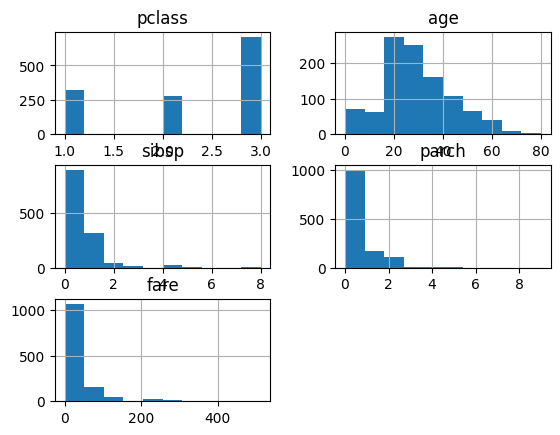

In [150]:
data[vars_num2].hist()

## Train the Logistic Regression model

- Set the regularization parameter to 0.0005
- Set the seed to 0

In [160]:
variables=['pclass', 'age', 'sibsp', 'parch', 'fare','age_na', 'fare_na',
       'sex_male', 'embarked_Missing', 'embarked_Q', 'embarked_S',
       'title_Miss', 'title_Mr', 'title_Mrs', 'title_Other',
       'cabin_first_letter_B', 'cabin_first_letter_C', 'cabin_first_letter_D',
       'cabin_first_letter_E', 'cabin_first_letter_F', 'cabin_first_letter_G',
       'cabin_first_letter_Missing', 'cabin_first_letter_T']

In [161]:
X_train=X_train[variables]
X_test=X_test[variables]

In [168]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(C=1/0.005, random_state=0)

model.fit(X_train, y_train)


y_train_pred_proba = model.predict_proba(X_train)[:, 1]
y_test_pred_proba = model.predict_proba(X_test)[:, 1]


## Make predictions and evaluate model performance

Determine:
- roc-auc
- accuracy

**Important, remember that to determine the accuracy, you need the outcome 0, 1, referring to survived or not. But to determine the roc-auc you need the probability of survival.**

In [167]:
accuracy = model.score(X_test, y_test)
train_roc_auc = roc_auc_score(y_train, y_train_pred_proba)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)
print(f"Accuracy: {accuracy}")
print(f"Train ROC AUC: {train_roc_auc}")
print(f"Test ROC AUC: {test_roc_auc}")

Accuracy: 0.8015267175572519
Train ROC AUC: 0.8625115919629057
Test ROC AUC: 0.8557716049382715


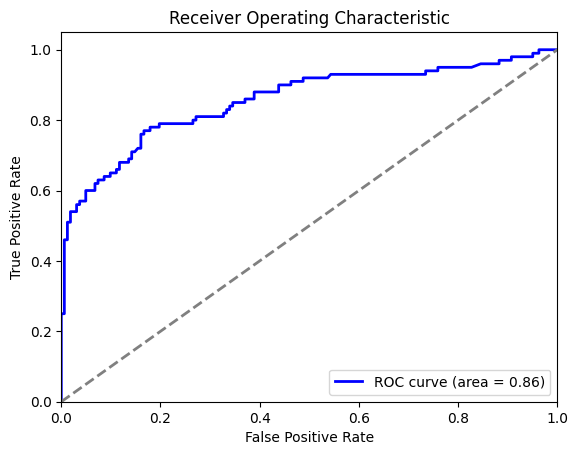

In [170]:
from sklearn.metrics import  roc_curve
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (area = %0.2f)' % test_roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

That's it! Well done

**Keep this code safe, as we will use this notebook later on, to build production code, in our next assignement!!**